In [88]:

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [89]:
df = pd.read_csv("dataset9000.csv")

df.head()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,Professional,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
1,Professional,Poor,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
2,Professional,Beginner,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
3,Professional,Average,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
4,Professional,Intermediate,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator


In [90]:
# Check Missing Values

print(df.isnull().sum())

Database Fundamentals              0
Computer Architecture              0
Distributed Computing Systems      0
Cyber Security                     0
Networking                         0
Software Development               0
Programming Skills                 0
Project Management                 0
Computer Forensics Fundamentals    0
Technical Communication            0
AI ML                              0
Software Engineering               0
Business Analysis                  0
Communication skills               0
Data Science                       0
Troubleshooting skills             0
Graphics Designing                 0
Role                               0
dtype: int64


In [91]:
# Remove Missing Values

df = df.dropna()

In [92]:
# Display Columns

print(df.columns)

Index(['Database Fundamentals', 'Computer Architecture',
       'Distributed Computing Systems', 'Cyber Security', 'Networking',
       'Software Development', 'Programming Skills', 'Project Management',
       'Computer Forensics Fundamentals', 'Technical Communication', 'AI ML',
       'Software Engineering', 'Business Analysis', 'Communication skills',
       'Data Science', 'Troubleshooting skills', 'Graphics Designing', 'Role'],
      dtype='object')


In [93]:
# Features and Target

X = df.drop("Role", axis=1)
y = df["Role"]

In [100]:
encoders = {}

for column in X.columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    encoders[column] = le

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [103]:
# Encode Target (y)
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [104]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [102]:
# Train Model

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
# Prediction

y_pred = model.predict(X_test)

In [106]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


In [107]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       117
           1       1.00      1.00      1.00       103
           2       1.00      1.00      1.00       115
           3       1.00      1.00      1.00       108
           4       1.00      1.00      1.00        99
           5       1.00      1.00      1.00       104
           6       1.00      1.00      1.00       113
           7       1.00      1.00      1.00       120
           8       1.00      1.00      1.00        91
           9       1.00      1.00      1.00       102
          10       1.00      1.00      1.00       100
          11       1.00      1.00      1.00       105
          12       1.00      1.00      1.00       105
          13       1.00      1.00      1.00        96
          14       1.00      1.00      1.00       118
          15       1.00      1.00      1.00       117
          16       1.00      1.00      1.00       123

    accuracy              

In [108]:
# Confusion Matrix

print(confusion_matrix(y_test, y_pred))

[[117   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 103   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 115   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 108   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0  99   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 104   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 113   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 120   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  91   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 102   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 100   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 105   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 105   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  96   0   0   0]
 [  0 

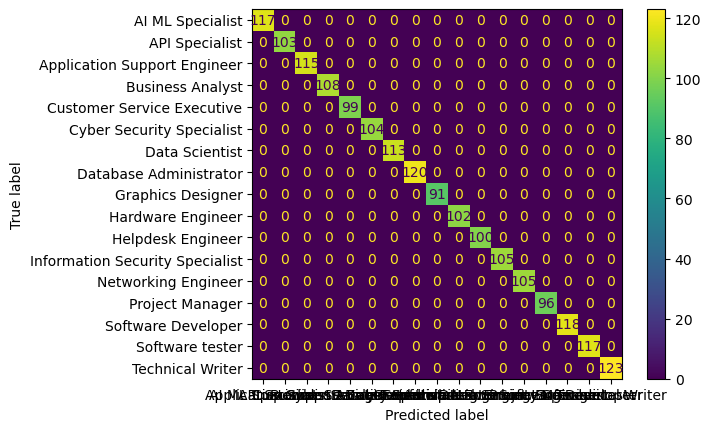

Confusion Matrix
[[117   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 103   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 115   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 108   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0  99   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 104   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 113   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 120   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  91   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 102   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 100   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 105   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 105   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  96   

In [109]:
#confusion matrix and accuracy score
from sklearn.metrics  import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)
Acc = accuracy_score(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_)
disp.plot()
plt.show()
print("Confusion Matrix")
print(cm)
print("Classification Report")
print(cr)
print("Accuracy Score")
print(Acc)

In [110]:
import pickle

with open("job_role_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

In [111]:
print(prediction)
print(type(prediction))
print(prediction.dtype)


[8]
<class 'numpy.ndarray'>
int64


In [113]:
import numpy as np
import pickle

# Load Model
with open("job_role_model.pkl", "rb") as file:
    model = pickle.load(file)

# Load Encoder
with open("label_encoder.pkl", "rb") as file:
    encoder = pickle.load(file)

print("Model Loaded Successfully")

db = int(input("Database Fundamentals: "))
ca = int(input("Computer Architecture: "))
dcs = int(input("Distributed Computing Systems: "))
cs = int(input("Cyber Security: "))
net = int(input("Networking: "))
sd = int(input("Software Development: "))
ps = int(input("Programming Skills: "))
pm = int(input("Project Management: "))
cff = int(input("Computer Forensics Fundamentals: "))
tc = int(input("Technical Communication: "))
aiml = int(input("AI ML: "))
se = int(input("Software Engineering: "))
ba = int(input("Business Analysis: "))
comm = int(input("Communication Skills: "))
ds = int(input("Data Science: "))
ts = int(input("Troubleshooting Skills: "))
gd = int(input("Graphics Designing: "))

data = np.array([[db, ca, dcs, cs, net, sd, ps, pm,
                  cff, tc, aiml, se, ba, comm, ds, ts, gd]])

prediction = model.predict(data)
role = encoder.inverse_transform(prediction)

print("\nPredicted Job Role:", role[0])

Model Loaded Successfully


Database Fundamentals:  1
Computer Architecture:  3
Distributed Computing Systems:  4
Cyber Security:  5
Networking:  6
Software Development:  7
Programming Skills:  8
Project Management:  9
Computer Forensics Fundamentals:  10
Technical Communication:  11
AI ML:  12
Software Engineering:  13
Business Analysis:  14
Communication Skills:  15
Data Science:  16
Troubleshooting Skills:  17
Graphics Designing:  18



Predicted Job Role: Graphics Designer


C:\Users\laksh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
